# Template for qspice simulation analysis

This is a template for running simulations programmatically with python and doing data analysis. Two examples are given: 

1. One with a simple dummy simulation (just a proof of concept);
2. Another with a boost PFC simulation, to preprocess the data and generate the exact sampled signals of a C program written to represent a microcontroller running an isr on a pwm periferic.

In [1]:
# Default packages

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from scipy.constants import c, pi
from scipy import signal
from matplotlib import cm
from numpy.fft import fft, fftshift


# For inline plots
%matplotlib inline

# plt.rcParams.update(
#     {
#         "text.usetex": True,
#         "font.family": "typeface",
#     }
# )  # Makes plotting slower but prettier (requires LaTeX installed)

# For debugging personal modules
# %load_ext autoreload
# %autoreload 2

## Example 1

This is a simple simulation where we want to plot the voltages on two nodes: Vout and dll_test. The workflow to run a simulation from a .qsch (Qspice schematic) file is the following:

1. First we import the required classes from the qspice module
2. Then we define a QschEditor class with the syntax QschEditor(PATH)
3. Next, we save it as a netlist inside a sim folder, just to keep things orgazined. This is done with the .save_netlist(PATH) method.
    - Since the simulation contains a dll file, we need to inform to the method the 'verilog_config', which is a dictionary containing information on the ports of the DLL object. Note that the dll file may not be necessarily written in verilog, it can be written in C++ or verilog. The verilog_config entry is a dictionary with the format {"Xn": ["port_type, data_type"]}, where Xn is the designator of the DLL file (X1, X2, Xtest, etc), "port_type" may be one of the types {in,out,common}; and data_type is the type of variable it represents (double64 = d, float32 = f, etc). This can be seen in qspice when inspecting the symbol properties of the dll block, under the pin nets section. Example (shown below): the pin 0 named 'out' of type double will show as 0 "out" (O´d), where 0 is the pin number, "out" is its name, 'O' represents output and 'd' stands for double. More details on the verilog_config may be found in the spicelib module from Nunobrun.

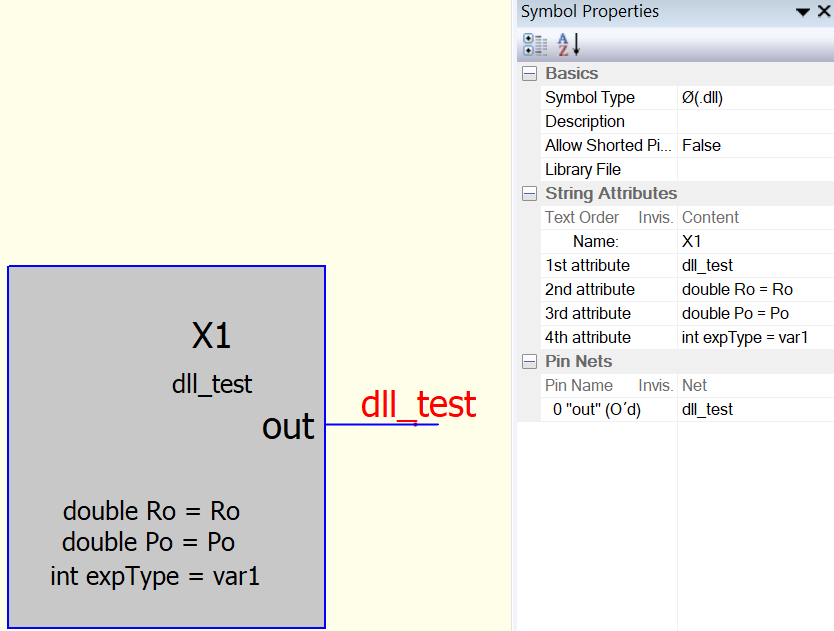

4. Then, we simulate with the 'run' method of the class 'SimRunner'. Do note that the .dll file must be present in the same folder used for temporary sim files (data in this case), so we copy the dll to this folder just in case.
5. The results of the simulation, as no callbacks were given, is an iterable inside SimRunner, so it can be accessed in a for loop or using the 'iter' and 'next' functions. The default output is a tuple (raw,log), in this order, where raw is the relative path to the raw file with the simulation data (same thing for the log file). To access the numerical results inside python, just use the RawRead class and its methods.

Known limitations: to change parameters with the 'set_param' method, if the parameter is a formula (anything other than just a number, e.g. 2+4, is a formula), the formula must come between brackets {}. This is mildly annoying, but it may be fixed in the future. I don't consider this relevant enough to create a fork of qspice to fix this. Another limitation, this one is more important though, is that you shouldn't use the prefix 'u' (micro) for numbers in your schematic. Qspice by default replaces the u by µ, which messes up the python module, so you should use 1e-6 instead. Other prefixes are fine. Hopefully this is fixed in the future.

To sum it up: make sure your schematics don't use parameters with u (fixed component values are fine). Also make sure that every parameter that is a formula is between brackets {}.

All components ['V1', 'R1', 'L1', 'X1']
Attempting to to compile [../sim/example1/dll_test.cpp] with dmc in [C:\Program Files\QSPICE\dm\bin\dmc.exe]
Compilation successful, deleting aux files.
Fri Mar 27 14:12:42 2026 info: RunTask #1:: Starting simulation 1: ..\data\example1_1.net

Fri Mar 27 14:12:42 2026 info: RunTask #1:Simulation Successful. Time elapsed: 00.0351 secs

Fri Mar 27 14:12:42 2026 debug: RunTask #1:Simulation Callback not called.



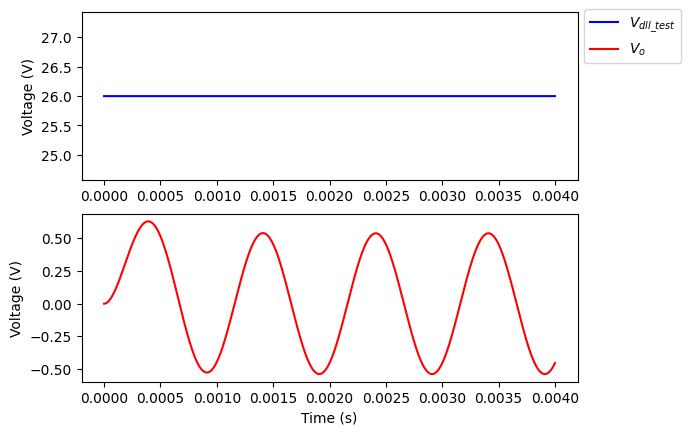

In [2]:
# 1. We use the qspice module from Nunobrun
from qspice import QschEditor, SimRunner, SpiceEditor, RawRead

# Some helper functions are in the following module
import qspice_utils

# 2. Defining the QschEditor class. We can also use it to modify the simulation, or get some information.
testSim = QschEditor("../sim/example1/test_sim1.qsch")
testSim.set_parameter("Po", 5)
testSim.set_parameter("Ro", 20)
testSim.set_component_value("L1", "5000u")


# Example: print every component inside the sim
print("All components", testSim.get_components())

# 3. Then we need to generate a netlist from que .qsch file. Since the schematic has a dll, we also need to inform the verilog config dictionary. Note that relationship between the dict and the info displayed in the properties inspector in qspice. We save the netlist in a separate data folder.
netName = "../data/example1.net"
testSim.save_netlist(netName, verilog_config={"X1": ["out,d"]})

# 4. Next, we call thhe simrunner to ouput the sim results in the same data folder and run the simulation. This will create another net file with a suffix _i (i.e. _1, _2, _3...) and a .qraw file of the same name.
runner = SimRunner(output_folder="../data")

# You can autogenerate the .dll file from a (valid) .c or .cpp file with the command
qspice_utils.gen_DLL_from_cpp(testSim, runner, "../sim/example1/dll_test.cpp")

# Run the sim
runner.run(netName)

# 5. Accessing the sim results is easy, we just iterate on the runner class itself and use the RawRead class to parse the results from the .qraw file to the raw_data object, where we can access any saved voltage or current with the get_wave method.
raw, log = next(iter(runner))
raw_data = RawRead(raw)

# Example: plotting the voltage of dll_test and vout
fig, ax = plt.subplots(nrows=2)
(line1,) = ax[0].plot(
    raw_data.get_wave("time"),
    raw_data.get_wave("V(dll_test)"),
    color="b",
    label="$V_{dll\_test}$",
)
ax[0].set_ylabel("Voltage (V)")
(line2,) = ax[1].plot(
    raw_data.get_wave("time"), raw_data.get_wave("V(Vo)"), color="r", label="$V_o$"
)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Voltage (V)")
fig.legend(handles=[line1, line2], loc="upper left", bbox_to_anchor=(0.9, 0.9))

# It's nice to clean up the files in the end
runner.cleanup_files()

## Example 2

Here we test a bridgeless totem-pole boost PFC converter schematic. We define some parameters and run 3 simulations as a test. Do not worry about the dll C code, as it's not the objective to explain it here in detail, but it just outputs switching pulses with the same duty-cycle of a parameter called duty_param. Our objective is, for the 3 simulations, save the sampled output signals of the dll block. For this we use the callback functionality of the qspice module.

In [3]:
# 2.
sim = QschEditor("../sim/example2/DDPFC_template.qsch")

# To get an organized parameter class with all of the parameters from the schematic, we use the utility function from qspice_utils
nomParams = qspice_utils.get_sim_params(sim)

# We are doing 3 sims with different conditions declared below. Note the .copy()
sim1_params = nomParams.copy()
sim2_params = nomParams.copy()
sim3_params = nomParams.copy()

If you run the cell above, your IDE might help to autocomplete the parameter's dictionary keys.

In [4]:
## Conditions for sims:
# 1st is just the nominal sim
# 2nd: we alter vin and ro
sim2_params["VLINE_RMS"] = 150
sim2_params["RO"] = 500

# 3rd: we alter noise 1 and 2 values
sim3_params["VAR1"] = 1e-3
sim3_params["var2"] = 1e-3
sim3_params["FREQ1"] = 80e3
sim3_params["FREQ2"] = 80e3

# 3.
netName = "../data/example2.net"

# To get the verilog file, the function below is utilized
example2_verilog_config = qspice_utils.build_verilog_config_ex2()

# 4. To run all sims
# Setting the runner
runner = SimRunner(output_folder="../data")
# Generating dll
qspice_utils.gen_DLL_from_cpp(sim, runner, "../sim/example2/digital_controller.cpp")
# Also copying line_voltage.txt to data, as all external file dependencies must be in the output folder of simRunner
shutil.copy2("../sim/example2/line_voltage.txt", "../data/")

# Batch sim
# we use a type ignore because the callback is not defined in spicelib to admit more than 2 args, but it works fine
for param in [sim1_params, sim2_params, sim3_params]:
    sim.set_parameters(**param)
    sim.save_netlist(netName, verilog_config=example2_verilog_config)
    net = SpiceEditor(netName)
    # Callback args
    call_args = {"simParams": param}
    runner.run(
        net, callback=qspice_utils.sample_voltages_callback, callback_args=call_args # type: ignore
    )  


df = qspice_utils.createTable(runner)
runner.cleanup_files()
print(f"Data collection complete. Net and raw files deleted.")

Attempting to to compile [../sim/example2/digital_controller.cpp] with dmc in [C:\Program Files\QSPICE\dm\bin\dmc.exe]
Compilation successful, deleting aux files.
Fri Mar 27 14:12:43 2026 info: RunTask #1:: Starting simulation 1: ..\data\example2_1.net

Fri Mar 27 14:12:43 2026 info: RunTask #2:: Starting simulation 2: ..\data\example2_2.net

Fri Mar 27 14:12:43 2026 info: RunTask #3:: Starting simulation 3: ..\data\example2_3.net

Fri Mar 27 14:13:00 2026 info: RunTask #1:Simulation Successful. Time elapsed: 17.0454 secs

Fri Mar 27 14:13:00 2026 info: RunTask #1:Simulation Finished. Calling...sample_voltages_callback(rawfile, logfilesimParams={'CO': 0.00027, 'FREQ1': 1.0, 'FREQ2': 1.0, 'FREQ3': 1.0, 'FS': 64800.0, 'HIIN_DC_GAIN': 1.0, 'HVIN_DC_GAIN': 1.0, 'HVO_DC_GAIN': 1.0, 'LB': 0.0032, 'LINE_FREQ': 60.0, 'MEAN1': 0.0, 'MEAN2': 0.0, 'MEAN3': 0.0, 'PARAM': 'ESR', 'PO': 300.0, 'REFSTEP_FLAG': 0.0, 'REFSTEP_MAG': 20.0, 'REND': 0.01, 'RO': '{380**2 / 300}', 'ROSTEP_FLAG': 0.0, 'RSTART'

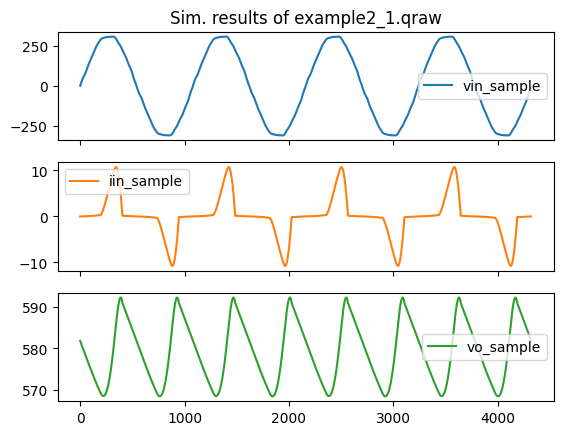

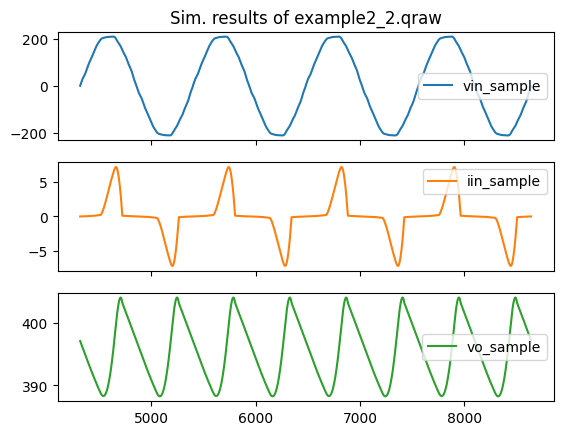

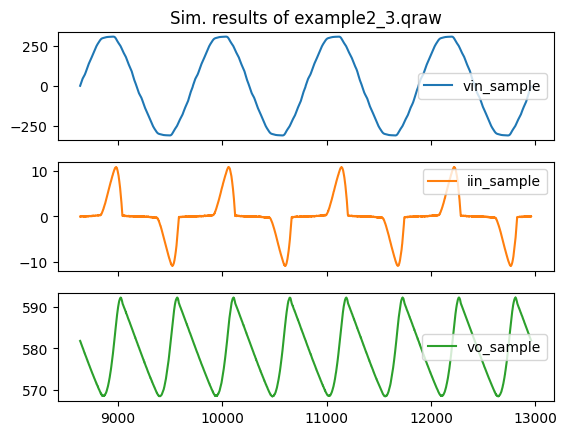

In [5]:
# Plotting every column for each 'simId' in a different subplot
for simId in df["simId"].unique():
    ax = df.loc[df["simId"] == simId, df.columns != "time"].plot(subplots=True)
    ax[0].set_title(f"Sim. results of {simId}")